# **Project Title :** **Advanced Statistical Analysis of NYC Taxi Trip Data**

# Project Objective :

The primary objective of this project is to analyze NYC Taxi trip data using descriptive and inferential statistical techniques to uncover meaningful patterns, relationships, and business insights.

The specific objectives are:

1. To understand the distribution and characteristics of taxi trips using descriptive statistics.

2. To analyze trip distance, fare amount, trip duration, passenger count, and tipping behavior.

3. To identify relationships between key variables such as trip distance, fare amount, and tip amount.

4. To perform hypothesis testing and group comparison analysis using statistical methods such as Correlation Analysis, T-Test, and ANOVA.

5. To evaluate differences in customer travel behavior across weekdays, weekends, and passenger groups.

6. To generate actionable business insights and recommendations that can support pricing strategies, operational planning, and revenue optimization.

7. To demonstrate the application of advanced statistical methods in solving real-world transportation and business problems.

# Problem Statement :

- The transportation industry generates large volumes of trip data every day. Understanding customer travel patterns, fare behavior, trip characteristics, and revenue drivers is essential for improving operational efficiency and business performance.

- The NYC Taxi dataset contains information about taxi trips, including trip distance, fare amount, passenger count, trip duration, and tipping behavior. However, raw data alone does not provide meaningful business insights.

- The challenge is to analyze the taxi trip data using statistical techniques to identify key factors influencing fare generation, customer behavior, and travel patterns. The findings can help taxi operators make data-driven decisions related to pricing, resource allocation, customer service, and revenue optimization.

In [1]:
# Importing required libraries for the project

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# **Data Understanding :**

In [2]:
# Loading the dataset
df = pd.read_csv("/content/cleaned_taxi_data_For_AdvStats_Analysis.csv")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,pickup_hour,pickup_day,day_of_week,month,trip_duration,fare_per_km,tip_percentage,trip_speed
0,2.0,2020-06-10 13:36:49,2020-06-10 13:51:08,1.0,2.73,1.0,N,224,148,2,...,15.30,2.5,13,10,Wednesday,6,14.316667,4.395604,0.000000,11.441211
1,2.0,2020-06-13 06:19:00,2020-06-13 06:37:00,1.0,11.58,1.0,N,56,42,1,...,35.73,0.0,6,13,Saturday,6,18.000000,2.487910,0.000000,38.600000
2,2.0,2020-06-20 07:59:23,2020-06-20 08:05:39,1.0,2.05,1.0,N,79,68,2,...,11.30,2.5,7,20,Saturday,6,6.266667,3.902439,0.000000,19.627660
3,1.0,2020-06-27 15:11:32,2020-06-27 15:15:02,1.0,1.40,1.0,N,236,75,1,...,11.15,2.5,15,27,Saturday,6,3.500000,4.285714,30.833333,24.000000
4,1.0,2020-06-26 16:00:36,2020-06-26 16:02:28,1.0,0.60,1.0,N,186,90,2,...,8.30,2.5,16,26,Friday,6,1.866667,6.666667,0.000000,19.285714


In [3]:
df.shape

(42306, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42306 entries, 0 to 42305
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               42306 non-null  float64
 1   tpep_pickup_datetime   42306 non-null  object 
 2   tpep_dropoff_datetime  42306 non-null  object 
 3   passenger_count        42306 non-null  float64
 4   trip_distance          42306 non-null  float64
 5   RatecodeID             42306 non-null  float64
 6   store_and_fwd_flag     42306 non-null  object 
 7   PULocationID           42306 non-null  int64  
 8   DOLocationID           42306 non-null  int64  
 9   payment_type           42306 non-null  int64  
 10  fare_amount            42306 non-null  float64
 11  extra                  42306 non-null  float64
 12  mta_tax                42306 non-null  float64
 13  tip_amount             42306 non-null  float64
 14  tolls_amount           42306 non-null  float64
 15  im

In [5]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'pickup_hour', 'pickup_day',
       'day_of_week', 'month', 'trip_duration', 'fare_per_km',
       'tip_percentage', 'trip_speed'],
      dtype='object')

In [6]:
required_columns = [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_duration',
    'pickup_hour',
    'day_of_week',
    'passenger_count'
]

for col in required_columns:
    print(col, "->", col in df.columns)

trip_distance -> True
fare_amount -> True
tip_amount -> True
total_amount -> True
trip_duration -> True
pickup_hour -> True
day_of_week -> True
passenger_count -> True


# **Descriptive Statistics :**

Descriptive statistics helps us summarize the dataset using:

- Mean
- Median
- Mode
- Standard Deviation
- Variance
- Minimum
- Maximum

Instead of looking at 42,306 rows individually, we will get a summary of the data.

- It also helps to describe the main features of the data.

In [7]:
stats_summary = df[
    [
        'trip_distance',
        'fare_amount',
        'tip_amount',
        'total_amount',
        'trip_duration'
    ]
].describe()

stats_summary

,trip_distance,fare_amount,tip_amount,total_amount,trip_duration
count,42306.000000,42306.000000,42306.000000,42306.000000,42306.000000
mean,3.494861,13.597099,1.821960,18.897323,12.326327
std,4.340681,12.919530,2.551185,14.558349,10.244241
min,0.010000,0.050000,0.000000,3.300000,0.016667
25%,1.100000,6.500000,0.000000,10.800000,5.666667
50%,1.920000,9.000000,1.580000,14.160000,9.450000
75%,3.800000,15.000000,2.750000,20.800000,15.766667
max,114.300000,332.000000,120.000000,409.700000,249.750000


In [8]:
# Calculating Mean, Median, Mode, Std, and Variance Seperately for better understanding...

for col in [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_duration'
]:

    print("\n", "="*40)
    print("Column:", col)

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())

    print("Mode:", df[col].mode()[0])

    print("Variance:",
          round(df[col].var(),2))

    print("Standard Deviation:",
          round(df[col].std(),2))


Column: trip_distance
Mean: 3.4948612489954143
Median: 1.92
Mode: 1.0
Variance: 18.84
Standard Deviation: 4.34

Column: fare_amount
Mean: 13.59709875667754
Median: 9.0
Mode: 5.5
Variance: 166.91
Standard Deviation: 12.92

Column: tip_amount
Mean: 1.8219604784191363
Median: 1.58
Mode: 0.0
Variance: 6.51
Standard Deviation: 2.55

Column: total_amount
Mean: 18.897322838368076
Median: 14.16
Mode: 8.8
Variance: 211.95
Standard Deviation: 14.56

Column: trip_duration
Mean: 12.326326840952424
Median: 9.45
Mode: 10.0
Variance: 104.94
Standard Deviation: 10.24


# **Observation :**

- The average trip distance was 3.49 miles, while the median distance was only 1.92 miles. Mean > Median, the distribution is right-skewed, indicating that most taxi rides are short-distance trips.

- The average fare was 13.60 dollars, while the median fare was only $9. This indicates that a small number of expensive rides significantly increase overall revenue.The large standard deviation confirms high variation in fare amounts.

- The most frequent tip amount was zero, indicating that many passengers did not leave tips. And the average tip was $1.82, tipping behavior varied substantially across customers.

- The average total trip value was 18.90 dollars, whereas the median value was $14.16. This difference indicates that a limited number of high-value trips contribute significantly to overall revenue.

- The average trip duration was approximately 12 minutes, while the median duration was around 9 minutes.This suggests that most trips are completed quickly, but some trips has taken more time showing evidence of occasional traffic-related delays.

In [9]:
# Calculating skewness and kurtosis

# Skewness : Skewness measures the asymmetry of data.

# Kurtosis : Kurtosis measures how extreme the outliers are.

from scipy.stats import skew, kurtosis

for col in [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_duration'
]:

    print("\n" + "="*50)
    print("Column:", col)

    print("Skewness:",
          round(skew(df[col]),2))

    print("Kurtosis:",
          round(kurtosis(df[col]),2))


Column: trip_distance
Skewness: 3.36
Kurtosis: 22.64

Column: fare_amount
Skewness: 3.51
Kurtosis: 28.05

Column: tip_amount
Skewness: 9.85
Kurtosis: 305.87

Column: total_amount
Skewness: 3.71
Kurtosis: 34.26

Column: trip_duration
Skewness: 3.37
Kurtosis: 35.85


# Observation :

All major variables show:

- High positive skewness
- Very high kurtosis

Therefore, We can observe that the NYC Taxi dataset does not follow a normal distribution and contains significant outliers.

# **Distribution of Fare_amount :**

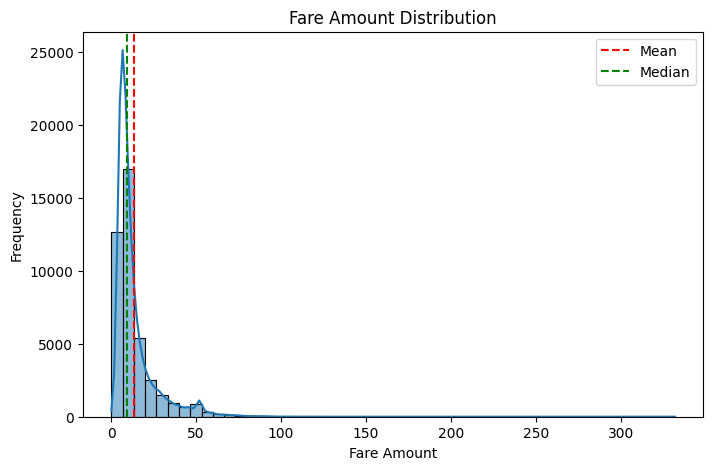

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['fare_amount'],
    bins=50,
    kde=True
)

plt.axvline(
    df['fare_amount'].mean(),
    color='red',
    linestyle='--',
    label='Mean'
)

plt.axvline(
    df['fare_amount'].median(),
    color='green',
    linestyle='--',
    label='Median'
)

plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Observation :
Most taxi fares are concentrated in the lower price range. The distribution is heavily right-skewed, indicating that while most trips generate moderate fares, a few high-value rides contribute significantly to overall revenue.

# **Distribution of Trip Distance :**

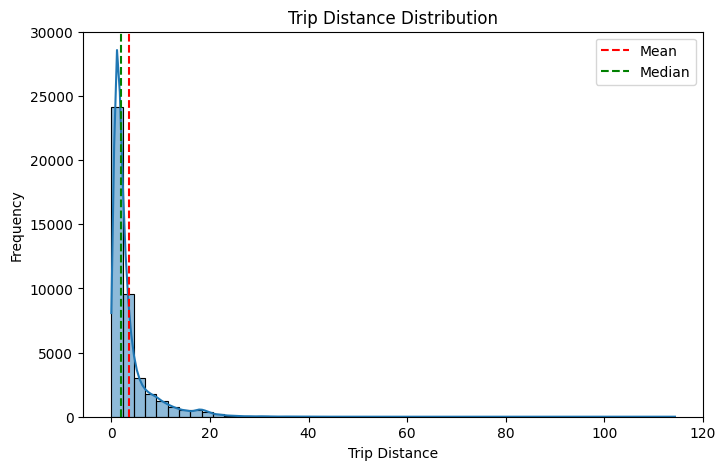

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['trip_distance'],
    bins=50,
    kde=True
)

plt.axvline(
    df['trip_distance'].mean(),
    color='red',
    linestyle='--',
    label='Mean'
)

plt.axvline(
    df['trip_distance'].median(),
    color='green',
    linestyle='--',
    label='Median'
)

plt.title("Trip Distance Distribution")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Observation :
The majority of taxi rides are short-distance trips, indicating that taxis primarily serve local transportation needs. Long-distance trips are relatively rare but contribute significantly to revenue generation.

# **Distribution of Tip Amount :**

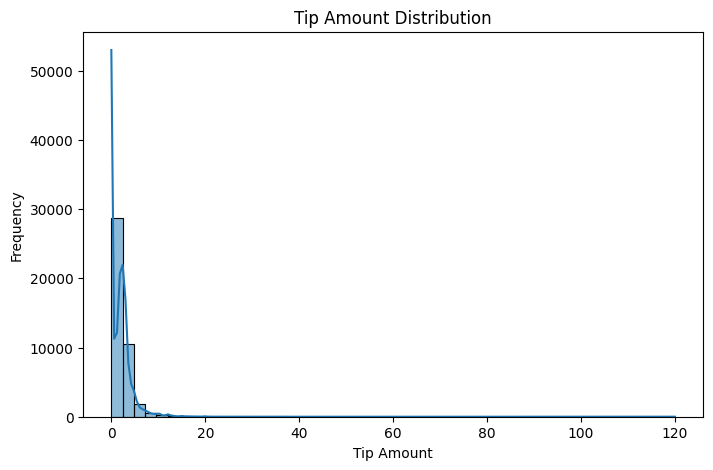

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['tip_amount'],
    bins=50,
    kde=True
)

plt.title("Tip Amount Distribution")

plt.xlabel("Tip Amount")

plt.ylabel("Frequency")

plt.show()

# Observation :
Tipping behavior is highly uneven. While many passengers leave no tip, a small number provide exceptionally large tips, resulting in an extremely skewed distribution.

# **Boxplot of Major variables :**

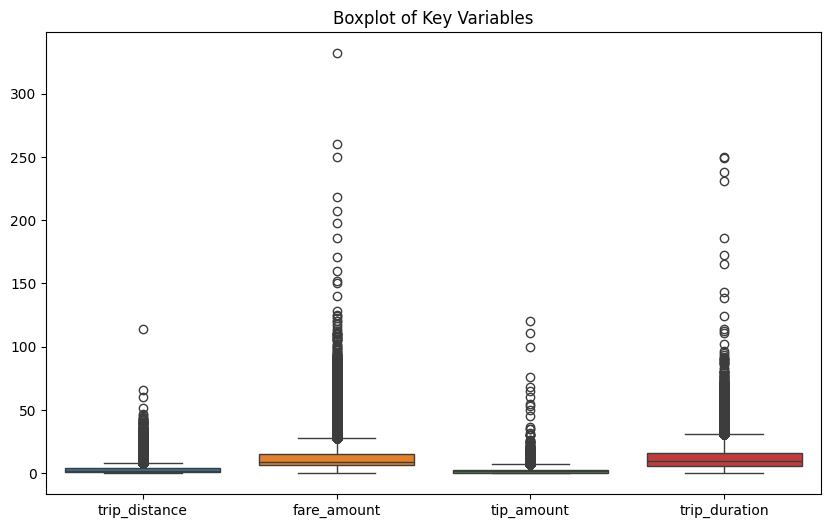

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[
        [
            'trip_distance',
            'fare_amount',
            'tip_amount',
            'trip_duration'
        ]
    ]
)

plt.title("Boxplot of Key Variables")

plt.show()

# Observation :
The boxplot reveals a substantial number of outliers across key variables. This aligns with the high kurtosis values observed earlier and indicates the presence of rare but impactful taxi trips.

# **Distribution of Coefficient of Variation Comparison :**

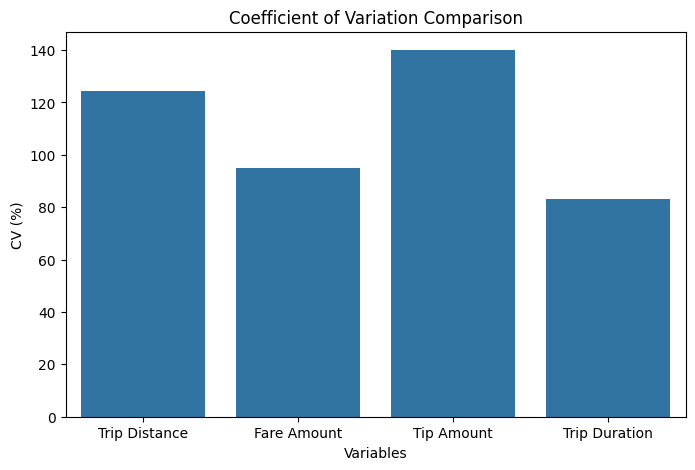

In [14]:
cv_data = pd.DataFrame({
    'Variable': ['Trip Distance',
                 'Fare Amount',
                 'Tip Amount',
                 'Trip Duration'],
    'CV': [
        (df['trip_distance'].std()/df['trip_distance'].mean())*100,
        (df['fare_amount'].std()/df['fare_amount'].mean())*100,
        (df['tip_amount'].std()/df['tip_amount'].mean())*100,
        (df['trip_duration'].std()/df['trip_duration'].mean())*100
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=cv_data,
    x='Variable',
    y='CV'
)

plt.title('Coefficient of Variation Comparison')
plt.ylabel('CV (%)')
plt.xlabel('Variables')

plt.show()

# Observation :
Among all analyzed variables, tipping behavior was the most unpredictable aspect of customer activity, whereas trip duration was relatively stable. This indicates that operational planning can rely more confidently on travel time estimates than on customer tipping patterns.

# **Confidence Interval :**

In [15]:
# Calculating confidence interval of fare_amount

from scipy.stats import norm
import numpy as np

mean_fare = df['fare_amount'].mean()

std_fare = df['fare_amount'].std()

n = len(df)

margin_error = norm.ppf(0.975) * (std_fare / np.sqrt(n))

lower = mean_fare - margin_error

upper = mean_fare + margin_error

print("Mean Fare:", round(mean_fare,2))
print("95% Confidence Interval:")
print(round(lower,2), "to", round(upper,2))

## Observation : By calculating the 95% confidence interval we can say that we are 95% confident that the interval ranged from $13.47 to $13.72, indicating that the average fare is highly stable and reliably estimated due to the large sample size of over 42,000 trips.

Mean Fare: 13.6
95% Confidence Interval:
13.47 to 13.72


# **Inferential Statistics :**

- Inferential statistics are used to make conclusions or predictions about a larger population using sample data.

# Hypothesis :

Null Hypothesis (H₀) : No relationship exists.(There is no significant relationship)

Alternative Hypothesis (H₁) : A relationship exists.(There is a significant relationship)

# Interpretation :

- p_value <= 0.05 ---> H0 : Rejected
- p_value > 0.05 ---> H0 : Accepted

Test 1: Relationship Between Trip Distance and Fare Amount

### Objective :

To determine whether trip distance has a significant impact on fare amount.

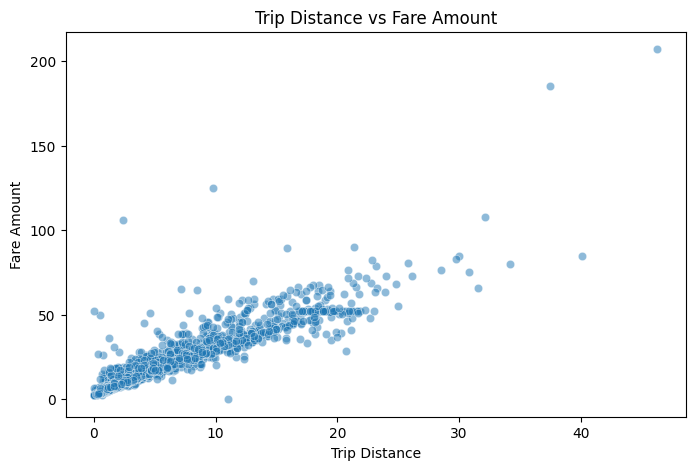

In [19]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x='trip_distance',
    y='fare_amount',
    alpha=0.5
)

plt.title("Trip Distance vs Fare Amount")

plt.xlabel("Trip Distance")

plt.ylabel("Fare Amount")

plt.show()

### Observation : The scatter plot shows an upward trend between trip distance and fare amount. As trip distance increases, fare amount also tends to increase. This suggests a positive relationship between trip distance and fare amount.

In [22]:
### Pearson Correlation Test (Statistical test)

from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['trip_distance'],
    df['fare_amount']
)

if p_value < 0.05:
    print("H0 Rejected")
else:
    print("Failed to Reject H0")

print("Correlation:", corr)
print("P-value:", p_value)

H0 Rejected
Correlation: 0.9427785515863458
P-value: 0.0


### Interpretation :

- The correlation coefficient between trip distance and fare amount is 0.9428, indicating a very strong positive relationship.

- The p-value is less than 0.05, which means the relationship is statistically significant.

- Therefore, the null hypothesis is rejected and the alternative hypothesis is accepted.

Test 2: Relationship Between Fare Amount and Tip Amount

### Objective :

To determine whether fare amount has a significant impact on tip amount.

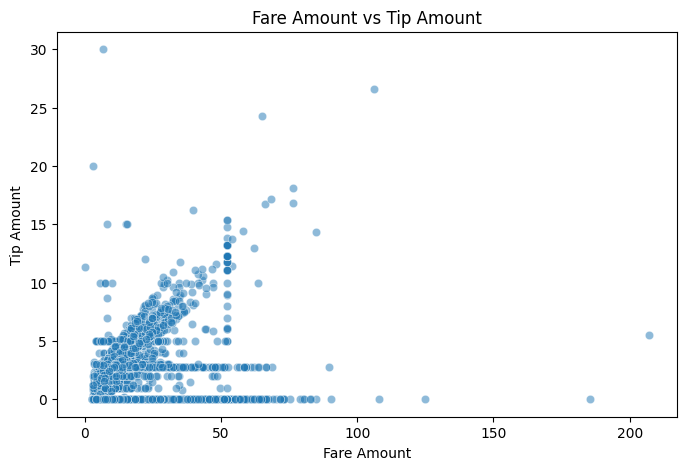

In [26]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x='fare_amount',
    y='tip_amount',
    alpha=0.5
)

plt.title("Fare Amount vs Tip Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Tip Amount")

plt.show()

### Observations :

# The scatter plot shows an overall upward trend between fare amount and tip amount.

# As fare amount increases, tip amount generally tends to increase. However, the relationship is not as strong as the relationship observed between trip distance and fare amount.

# A large number of customers leave low or zero tips regardless of fare amount, while a smaller group of customers leave higher tips for higher fare rides.

# This suggests a weak positive relationship between fare amount and tip amount.

In [25]:
# Pearson correlation test

from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['fare_amount'],
    df['tip_amount']
)

print("Correlation Coefficient =", corr)
print("P-value =", p_value)

if p_value < 0.05:
    print("H0 Rejected")
else:
    print("Failed to Reject H0")

Correlation Coefficient = 0.2846550990549635
P-value = 0.0
H0 Rejected


### Interpretation :

- The correlation coefficient between fare amount and tip amount is 0.2847, indicating a weak positive relationship.

- The p-value is less than 0.05, which means the relationship is statistically significant.

- Therefore, the null hypothesis is rejected.

Test 3: Comparison of Trip Distance Between Weekdays and Weekends

### Objective :

To determine whether average trip distance differs significantly between weekdays and weekends.

In [30]:
print("Weekday Trips :", len(weekday))
print("Weekend Trips :", len(weekend))

print("\nUnique Day Names:")
print(df['day_of_week'].unique())

Weekday Trips : 34184
Weekend Trips : 8122

Unique Day Names:
['Wednesday' 'Saturday' 'Friday' 'Monday' 'Tuesday' 'Sunday' 'Thursday']


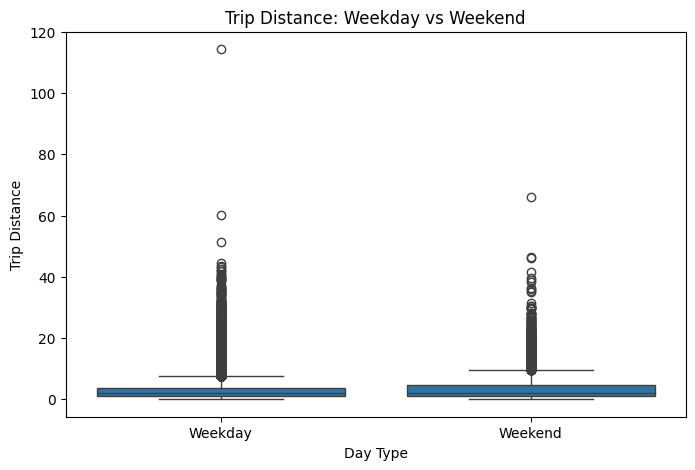

In [29]:
comparison_df = pd.DataFrame({
    'trip_distance': pd.concat([
        weekday['trip_distance'],
        weekend['trip_distance']
    ]),
    'Day_Type': (
        ['Weekday'] * len(weekday)
        +
        ['Weekend'] * len(weekend)
    )
})

plt.figure(figsize=(8,5))

sns.boxplot(
    data=comparison_df,
    x='Day_Type',
    y='trip_distance'
)

plt.title("Trip Distance: Weekday vs Weekend")

plt.xlabel("Day Type")

plt.ylabel("Trip Distance")

plt.show()

### Observation :

- The boxplot shows that both weekday and weekend trip distances have similar distributions.

- Both groups contain several outliers, indicating the presence of some unusually long-distance taxi rides.

- Based on the visualization, there may be a difference between weekday and weekend trip distances, but a statistical test is required to confirm whether the difference is significant.

### Hypothesis

**Null Hypothesis (H₀):**

There is no significant difference in average trip distance between weekdays and weekends.

**Alternative Hypothesis (H₁):**

There is a significant difference in average trip distance between weekdays and weekends.

In [34]:
# T-test - used when comparing two groups ---> Statistical test

from scipy.stats import ttest_ind

t_value, p_value = ttest_ind(
    weekday['trip_distance'],
    weekend['trip_distance']
)

print("t_value =", t_value)
print("p_value =", p_value)

if p_value < 0.05:
    print("H0 Rejected")
else:
    print("Failed to Reject H0")

t_value = -9.039367342429587
p_value = 1.640719692757746e-19
H0 Rejected


### Interpretation :

- The p-value is less than 0.05, indicating that the difference in average trip distance between weekdays and weekends is statistically significant.

- Weekend trips tend to have slightly higher trip distances compared to weekday trips.

- Therefore, the null hypothesis is rejected.

Test 4: Comparison of Fare Amount Across Passenger Groups

### Objective :

To determine whether average fare amount differs significantly across passenger count groups.

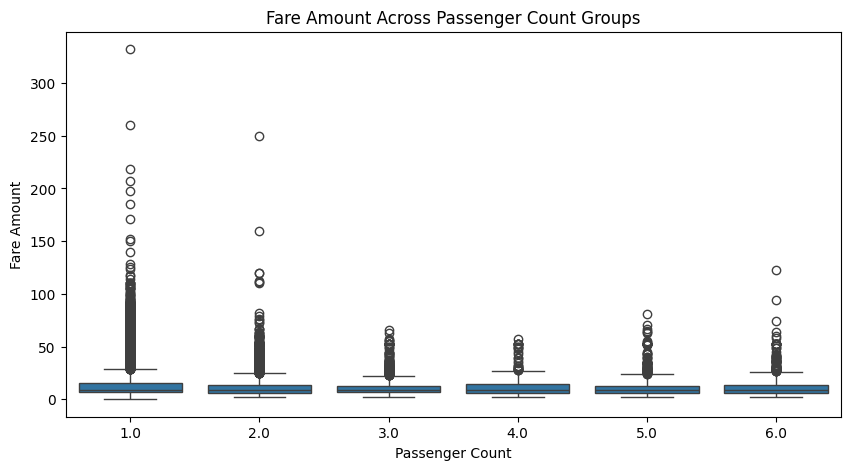

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='passenger_count',
    y='fare_amount'
)

plt.title("Fare Amount Across Passenger Count Groups")

plt.xlabel("Passenger Count")

plt.ylabel("Fare Amount")

plt.show()

### Observation :

- The boxplot shows that fare amounts vary across different passenger count groups.

- The median fare values appear relatively similar across groups, although slight differences can be observed.

- Passenger count groups 1 and 2 contain a larger number of high-fare outliers compared to other groups.

- Based on the visualization, there may be differences in average fare amounts among passenger groups, but a statistical test is required to determine whether these differences are significant.

### Hypothesis

**Null Hypothesis (H₀):**

The average fare amount is the same across all passenger count groups.

**Alternative Hypothesis (H₁):**

At least one passenger count group has a significantly different average fare amount.

In [37]:
# ANOVA (Analysis of Variance) - used when comparing multiple(more than 2) groups. ---> Statistical test

from scipy.stats import f_oneway

g1 = df[df['passenger_count']==1]['fare_amount']
g2 = df[df['passenger_count']==2]['fare_amount']
g3 = df[df['passenger_count']==3]['fare_amount']
g4 = df[df['passenger_count']==4]['fare_amount']
g5 = df[df['passenger_count']==5]['fare_amount']
g6 = df[df['passenger_count']==6]['fare_amount']

f_value, p_value = f_oneway(
    g1, g2, g3, g4, g5, g6
)

print("F-value =", f_value)
print("P-value =", p_value)

if p_value < 0.05:
    print("H0 Rejected")
else:
    print("Failed to Reject H0")

F-value = 26.407088908688525
P-value = 9.709880596480591e-27
H0 Rejected


### Interpretation :

- The p-value is less than 0.05, indicating that there is a statistically significant difference in average fare amounts among passenger count groups.

- Different passenger groups exhibit different fare patterns.This suggests that passenger count has an influence on fare amount.

- Therefore, the null hypothesis is rejected.


In [38]:
print("Weekday Mean Distance:",
      weekday['trip_distance'].mean())

print("Weekend Mean Distance:",
      weekend['trip_distance'].mean())

print("\nAverage Fare by Passenger Count")

print(
    df.groupby('passenger_count')['fare_amount']
      .mean()
)

Weekday Mean Distance: 3.401964369295577
Weekend Mean Distance: 3.8858470819995072

Average Fare by Passenger Count
passenger_count
1.0    13.931857
2.0    12.273206
3.0    11.648228
4.0    12.441595
5.0    11.483907
6.0    12.341892
Name: fare_amount, dtype: float64


# **Business Insights :**

# Business Insight 1 : Short-Distance Trips Dominate Taxi Demand

In [41]:
print("Mean Distance:", round(df['trip_distance'].mean(),2))
print("Median Distance:", round(df['trip_distance'].median(),2))

# The median trip distance (1.92 miles) is significantly lower than the mean distance (3.49 miles), indicating that most taxi rides are short-distance trips. This suggests that NYC taxis primarily serve local commuting and urban transportation needs.

Mean Distance: 3.49
Median Distance: 1.92


# Business Insight 2: Revenue is Driven by a Small Number of High-Value Trips

In [42]:
print(df['fare_amount'].describe())

# The maximum fare ($332) is substantially higher than the average fare ($13.60), indicating that a small number of high-value trips contribute disproportionately to overall revenue.

count    42306.000000
mean        13.597099
std         12.919530
min          0.050000
25%          6.500000
50%          9.000000
75%         15.000000
max        332.000000
Name: fare_amount, dtype: float64


# Business Insight 3: Distance Strongly Influences Fare

In [45]:
corr, p_value = pearsonr(
    df['trip_distance'],
    df['fare_amount']
)

print("Correlation =", round(corr,4))

# Trip distance and fare amount exhibit a very strong positive correlation (0.9428). This confirms that fare generation is primarily driven by trip distance, validating the effectiveness of the distance-based pricing model.

Correlation = 0.9428


# Business Insight 4: Tipping Behavior is Highly Variable

In [47]:
print("Mode Tip:",
      df['tip_amount'].mode()[0])

print("CV:",
      round(
          (df['tip_amount'].std() /
           df['tip_amount'].mean())*100,
          2
      ))

# The most frequent tip amount is zero, and the coefficient of variation exceeds 100%, indicating highly inconsistent tipping behavior among customers.

Mode Tip: 0.0
CV: 140.02


# Business Insight 5: Weekend Trips are Longer

In [49]:
print(
    "Weekday Mean Distance:",
    round(
        weekday['trip_distance'].mean(),
        2
    )
)

print(
    "Weekend Mean Distance:",
    round(
        weekend['trip_distance'].mean(),
        2
    )
)

# Weekend trips are longer on average than weekday trips, suggesting that customers undertake more leisure, shopping, and recreational travel during weekends.

Weekday Mean Distance: 3.4
Weekend Mean Distance: 3.89


# Business Insight 6: Single-Passenger Trips Generate Highest Revenue

In [51]:
df.groupby(
    'passenger_count'
)['fare_amount'].mean()

# Single-passenger rides generate the highest average fare amount, highlighting individual travelers as a key revenue-generating customer segment.

,fare_amount
passenger_count,
1.0,13.931857
2.0,12.273206
3.0,11.648228
4.0,12.441595
5.0,11.483907
6.0,12.341892


# Business Insight 7: Outlier Trips Have Significant Revenue Impact

In [53]:
print(
    "Maximum Distance:",
    df['trip_distance'].max()
)

print(
    "Maximum Fare:",
    df['fare_amount'].max()
)

# Although rare, extremely long-distance and high-fare trips contribute substantially to revenue and represent important travel segments such as airport and inter-city transportation.

Maximum Distance: 114.3
Maximum Fare: 332.0


# **Strategic Recommendations : (Based on Business Insights)**

## Recommendation 1: Increase Driver Availability in High-Demand Urban Areas

- Since the majority of taxi trips are short-distance rides, taxi operators should focus on maintaining high driver availability in densely populated urban areas.

- This can reduce passenger waiting times, improve ride completion rates, and increase daily trip volume.

## Recommendation 2: Prioritize High-Value Travel Corridors

- Taxi operators should identify and prioritize routes that consistently generate high fares, such as airport transfers and major transit hubs.

- Allocating more drivers to these areas can increase overall revenue and improve service availability for high-value customers.

## Recommendation 3: Maintain and Optimize Distance-Based Pricing

- The strong relationship between trip distance and fare amount confirms that the existing distance-based pricing model is effective.

- Taxi operators should continue using distance as a primary pricing factor while periodically reviewing fare structures to ensure competitiveness and profitability.

## Recommendation 4: Improve Customer Experience to Encourage Tipping

- Since tipping behavior is not strongly linked to fare amount, improving customer satisfaction may help increase tip revenue.

- Driver training, cleaner vehicles, and enhanced ride experiences can encourage customers to provide higher tips.

## Recommendation 5: Increase Driver Allocation During Weekends

- Weekend trips tend to be longer than weekday trips, indicating different travel patterns.

- Taxi operators should consider increasing driver availability during weekends to meet demand for longer leisure and recreational trips.

## Recommendation 6: Focus on Individual Travelers

- Single-passenger rides contribute the highest average fare revenue.

- Taxi operators can target individual travelers, commuters, and business passengers through loyalty programs, corporate partnerships, and airport services.

## Recommendation 7: Monitor and Analyze High-Value Outlier Trips

- Although rare, extremely long-distance and high-fare trips contribute significantly to overall revenue.

- Regular analysis of these trips can help identify profitable travel corridors and support strategic planning for driver deployment.

# **Conclusion :**

- In this project, I analyzed the NYC Taxi dataset to understand customer travel patterns, fare behavior, and revenue trends using descriptive statistics, inferential statistics, and business analysis techniques.

- The analysis showed that most taxi trips are short-distance rides, indicating that taxis are mainly used for local transportation. It was also observed that a small number of long-distance trips contribute a significant portion of the overall revenue. Through statistical testing, I found a strong positive relationship between trip distance and fare amount, confirming that distance is a key factor influencing taxi fares.

- The study also revealed differences in travel behavior between weekdays and weekends, with weekend trips generally being longer. Additionally, fare patterns varied across different passenger groups, highlighting the importance of understanding customer segments.

- Overall, this project helped transform raw taxi trip data into meaningful insights. The findings can support better decision-making in areas such as pricing strategies, driver allocation, customer experience, and revenue optimization. This demonstrates how statistical analysis can be used to solve real-world business problems and generate actionable recommendations.